# Fashion-MNIST Vanilla CNN Baseline



In [1]:
# !pip install torch
# !pip install torchvision
# !pip install matplotlib

In [2]:
# 라이브러리 불러오기 

import time
import warnings

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")


ModuleNotFoundError: No module named 'torchvision'

# Data Loading

[data] Fashion-MNIST

- 기존 대비 데이터만 좀 바뀐 정도.

- 28×28 grayscale 의류 이미지, 클래스 10개
- Train 60,000 / Test 10,000
- MNIST와 이미지 크기는 같고, 분류 난이도는 더 높음

In [ ]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(
            (0.5,),  # 평균 0.5
            (0.5,),  # 표준편차 0.5
        ),
    ]
)

In [ ]:
# 데이터셋 불러오기

train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

In [ ]:
# train_set 중 일부를 validation set으로 분리 (train 90% / valid 10%)
valid_ratio = 0.1
train_size = int(len(train_set) * (1 - valid_ratio))
valid_size = len(train_set) - train_size

train_subset, valid_subset = torch.utils.data.random_split(
    train_set,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

# 시드값을 고정해서 동일한 데이터셋 분할을 재현 가능하게 함 
# 숫자 선정은 자유롭게 하면 된다. 

In [ ]:
# 데이터셋 확인 
print(f"train_set size: {len(train_subset)}")
print(f"valid_set size: {len(valid_subset)}")
print(f"test_set size: {len(test_set)}")

train_set size: 54000
valid_set size: 6000
test_set size: 10000


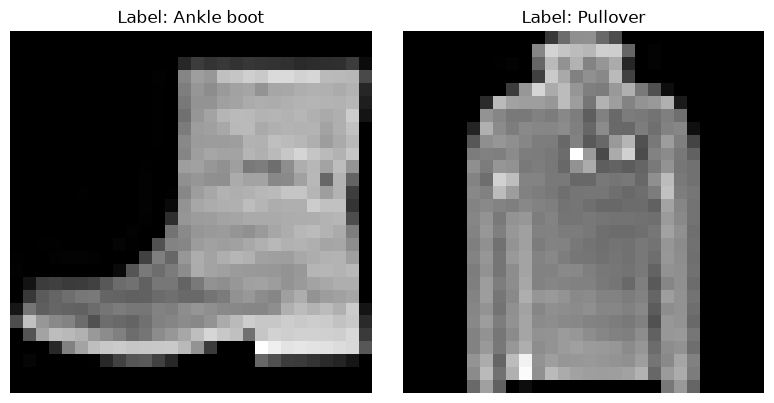

In [ ]:
# 이미지 확인 

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
    image, label = train_subset[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {CLASS_NAMES[label]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


일단 데이터 로딩까지는 다 되었고, 로딩 데이터로 학습을 하면 된다.

# Baseline Model & Training

이 Baseline은 `10-cnn.ipynb`의 Vanilla CNN 구조를 Fashion-MNIST에 적용한다.

- 모델 구조: `Conv → ReLU → Pool → Conv → ReLU → Pool → FC → ReLU → FC`
- Optimizer: Adam
- Loss: CrossEntropyLoss
- 학습 횟수: 10 epochs
- 비교 기준을 만들기 위한 모델이므로 Dropout, BatchNorm, Early Stopping은 적용하지 않는다.

## MPS 설정 (맥북 파이토치 GPU 설정)

In [ ]:
device = torch.device("mps")

# 실제 텐서가 MPS에 생성되는지 확인한다.
mps_test_tensor = torch.zeros(1, device=device)

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")
print(f"Test tensor device: {mps_test_tensor.device}")

assert device.type == "mps"
assert mps_test_tensor.device.type == "mps"
del mps_test_tensor


PyTorch version: 2.13.0
Selected device: mps
Test tensor device: mps:0


## 1. Baseline 설정과 DataLoader

In [ ]:
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
RANDOM_SEED = 42

# 모델 초기화와 DataLoader 셔플 순서를 최대한 동일하게 재현
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

train_generator = torch.Generator().manual_seed(RANDOM_SEED)

train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
)

valid_loader = torch.utils.data.DataLoader(
    valid_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"train batches: {len(train_loader)}")
print(f"valid batches: {len(valid_loader)}")
print(f"test batches: {len(test_loader)}")

train batches: 1688
valid batches: 188
test batches: 313


## 2. Vanilla CNN Architecture

Fashion-MNIST도 MNIST와 동일한 `1 × 28 × 28` 흑백 이미지이므로 10번과 같은 CNN 입력 구조를 사용한다.

In [ ]:
class CNN(nn.Module):
    def __init__(self, dropout_p=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


### Tensor Shape

한 눈에 보는 Tensor Shape !
(for 우리 팀원들)

| 단계 | 출력 Shape |
|---|---|
| 입력 | `[B, 1, 28, 28]` |
| Conv1 + ReLU | `[B, 32, 28, 28]` |
| MaxPool | `[B, 32, 14, 14]` |
| Conv2 + ReLU | `[B, 64, 14, 14]` |
| MaxPool | `[B, 64, 7, 7]` |
| Flatten | `[B, 3136]` |
| FC1 + ReLU | `[B, 128]` |
| FC2 | `[B, 10]` |

## 3. Baseline 학습

In [ ]:
# 기본 베이스라인 코드, 10번 파일에 

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Model device: {next(model.parameters()).device}")
print(
    f"Trainable parameters: "
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

Model device: mps:0
Trainable parameters: 421,642


In [ ]:
# 10번 파일 코드를 재사용한다. 

train_losses = []
valid_losses = []
valid_accuracies = []

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    valid_running_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            valid_running_loss += loss.item()

            predicted = outputs.argmax(dim=1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    valid_loss = valid_running_loss / len(valid_loader)
    valid_accuracy = valid_correct / valid_total
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | "
        f"Valid Accuracy: {valid_accuracy:.4f}"
    )

Epoch [01/10] Train Loss: 0.4162 | Valid Loss: 0.3096 | Valid Accuracy: 0.8843
Epoch [02/10] Train Loss: 0.2676 | Valid Loss: 0.2549 | Valid Accuracy: 0.9042
Epoch [03/10] Train Loss: 0.2188 | Valid Loss: 0.2411 | Valid Accuracy: 0.9082


KeyboardInterrupt: 

## 4. Baseline 평가

In [ ]:
def evaluate(model, loader, criterion=None, collect_misclassified=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    misclassified = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)

            if criterion is not None:
                running_loss += criterion(outputs, labels).item()

            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()

            if collect_misclassified:
                wrong_indices = (predictions != labels).nonzero(as_tuple=True)[0]
                misclassified.extend(
                    (
                        inputs[index].detach().cpu(),
                        predictions[index].item(),
                        labels[index].item(),
                    )
                    for index in wrong_indices
                )

    average_loss = running_loss / len(loader) if criterion is not None else None
    return average_loss, correct / total, misclassified


### 결과 출력

In [ ]:


_, train_accuracy, _ = evaluate(model, train_loader)
_, valid_accuracy, _ = evaluate(model, valid_loader)
_, test_accuracy, misclassified_samples = evaluate(
    model,
    test_loader,
    collect_misclassified=True,
)

baseline_results = {
    "train_accuracy": train_accuracy,
    "validation_accuracy": valid_accuracy,
    "test_accuracy": test_accuracy,
    "final_train_loss": train_losses[-1],
    "best_validation_loss": min(valid_losses),
    "best_epoch": valid_losses.index(min(valid_losses)) + 1,
}

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Train Loss: {baseline_results['final_train_loss']:.4f}")
print(f"Best Validation Loss: {baseline_results['best_validation_loss']:.4f}")
print(f"Best Epoch: {baseline_results['best_epoch']}")


Train Accuracy: 0.9877
Validation Accuracy: 0.9257
Test Accuracy: 0.9185
Final Train Loss: 0.0628
Best Validation Loss: 0.2211
Best Epoch: 4


## 5. Baseline Loss 확인

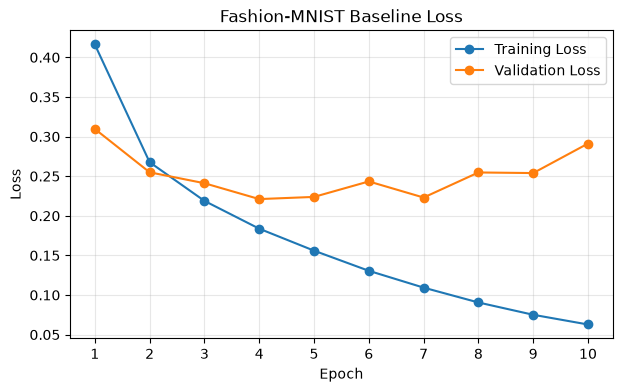

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, valid_losses, marker="o", label="Validation Loss")
plt.title("Fashion-MNIST Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Baseline 예측 결과 확인

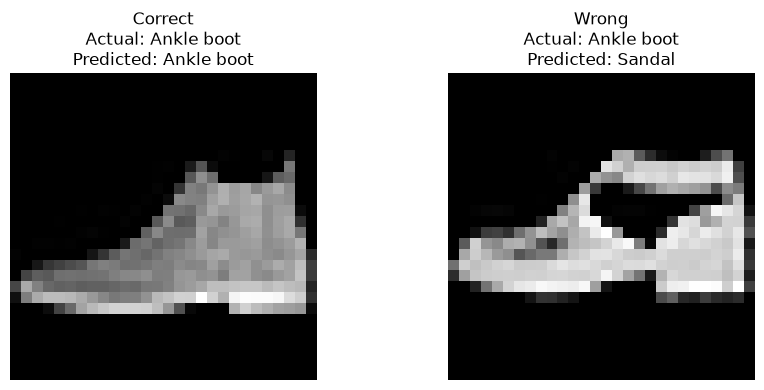

In [ ]:
# 맞힌 샘플 한 개 찾기
correct_sample = None
model.eval()

with torch.no_grad():
    for image, label in test_set:
        output = model(image.unsqueeze(0).to(device))
        prediction = output.argmax(dim=1).item()
        if prediction == label:
            correct_sample = (image, prediction, label)
            break

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

if correct_sample is not None:
    image, prediction, label = correct_sample
    axes[0].imshow(image.squeeze(), cmap="gray")
    axes[0].set_title(
        f"Correct\nActual: {CLASS_NAMES[label]}\nPredicted: {CLASS_NAMES[prediction]}"
    )
    axes[0].axis("off")

if misclassified_samples:
    image, prediction, label = misclassified_samples[0]
    axes[1].imshow(image.squeeze(), cmap="gray")
    axes[1].set_title(
        f"Wrong\nActual: {CLASS_NAMES[label]}\nPredicted: {CLASS_NAMES[prediction]}"
    )
    axes[1].axis("off")

plt.tight_layout()
plt.show()

### Baseline Confusion Matrix와 클래스별 정확도

Test 데이터 10,000개의 실제 클래스와 Baseline 예측 클래스를 비교한다. 행은 실제 클래스, 열은 예측 클래스를 뜻한다.


## 1. 공통 학습 함수

개인별 실험은 앞에서 정의한 CNN과 공통 학습 함수를 사용한다.

In [ ]:
def reset_experiment_seed(seed=RANDOM_SEED):
    torch.manual_seed(seed)


def make_experiment_loaders(seed=RANDOM_SEED):
    generator = torch.Generator().manual_seed(seed)
    experiment_train_loader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )
    train_eval_loader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    experiment_valid_loader = torch.utils.data.DataLoader(
        valid_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    experiment_test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    return (
        experiment_train_loader,
        train_eval_loader,
        experiment_valid_loader,
        experiment_test_loader,
    )


def run_experiment(name, epochs, learning_rate, dropout_p):
    reset_experiment_seed()
    (
        experiment_train_loader,
        train_eval_loader,
        experiment_valid_loader,
        experiment_test_loader,
    ) = make_experiment_loaders()

    experiment_model = CNN(dropout_p=dropout_p).to(device)
    experiment_criterion = nn.CrossEntropyLoss()
    experiment_optimizer = optim.Adam(
        experiment_model.parameters(),
        lr=learning_rate,
    )
    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_accuracy": [],
        "valid_accuracy": [],
    }

    torch.mps.synchronize()
    started_at = time.perf_counter()

    for epoch in range(epochs):
        experiment_model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in experiment_train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            experiment_optimizer.zero_grad()
            outputs = experiment_model(inputs)
            loss = experiment_criterion(outputs, labels)
            loss.backward()
            experiment_optimizer.step()

            train_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predictions == labels).sum().item()

        train_loss = train_running_loss / len(experiment_train_loader)
        train_accuracy_epoch = train_correct / train_total
        valid_loss, valid_accuracy_epoch, _ = evaluate(
            experiment_model,
            experiment_valid_loader,
            experiment_criterion,
        )

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_accuracy"].append(train_accuracy_epoch)
        history["valid_accuracy"].append(valid_accuracy_epoch)

        print(
            f"{name} | Epoch [{epoch + 1:02d}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Valid Loss: {valid_loss:.4f} | "
            f"Valid Accuracy: {valid_accuracy_epoch:.4f}"
        )

    torch.mps.synchronize()
    duration_seconds = time.perf_counter() - started_at

    train_eval_loss, train_accuracy_final, _ = evaluate(
        experiment_model,
        train_eval_loader,
        experiment_criterion,
    )
    valid_eval_loss, valid_accuracy_final, _ = evaluate(
        experiment_model,
        experiment_valid_loader,
        experiment_criterion,
    )
    test_eval_loss, test_accuracy_final, _ = evaluate(
        experiment_model,
        experiment_test_loader,
        experiment_criterion,
    )

    best_valid_loss = min(history["valid_loss"])
    result = {
        "name": name,
        "epochs": epochs,
        "learning_rate": learning_rate,
        "dropout": dropout_p,
        "train_accuracy": train_accuracy_final,
        "valid_accuracy": valid_accuracy_final,
        "test_accuracy": test_accuracy_final,
        "train_eval_loss": train_eval_loss,
        "final_train_loss": history["train_loss"][-1],
        "final_valid_loss": valid_eval_loss,
        "test_loss": test_eval_loss,
        "best_valid_loss": best_valid_loss,
        "best_epoch": history["valid_loss"].index(best_valid_loss) + 1,
        "generalization_gap": train_accuracy_final - valid_accuracy_final,
        "duration_seconds": duration_seconds,
        "parameters": sum(p.numel() for p in experiment_model.parameters()),
    }
    return result, history


## 2. Baseline 비교 데이터 준비

In [ ]:
# Baseline 결과를 개인별 실험과 같은 형식으로 정리한다.
# 선정 : epoch = 4 
# 유리 : LR = 0.0005
# 민형 : Dropout = 0.2

baseline_record = {
    "name": "Baseline",
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "dropout": 0.0,
    "train_accuracy": train_accuracy,
    "valid_accuracy": valid_accuracy,
    "test_accuracy": test_accuracy,
    "train_eval_loss": float("nan"),
    "final_train_loss": train_losses[-1],
    "final_valid_loss": valid_losses[-1],
    "test_loss": float("nan"),
    "best_valid_loss": min(valid_losses),
    "best_epoch": valid_losses.index(min(valid_losses)) + 1,
    "generalization_gap": train_accuracy - valid_accuracy,
    "duration_seconds": float("nan"),
    "parameters": sum(p.numel() for p in model.parameters()),
}

experiment_results = [baseline_record]
experiment_histories = {
    "Baseline": {
        "train_loss": list(train_losses),
        "valid_loss": list(valid_losses),
        "valid_accuracy": list(valid_accuracies),
    }
}


def register_experiment(result, history):
    # 같은 개인 셀을 다시 실행해도 결과가 중복되지 않도록 교체한다.
    experiment_results[:] = [
        saved_result
        for saved_result in experiment_results
        if saved_result["name"] != result["name"]
    ]
    experiment_results.append(result)
    experiment_histories[result["name"]] = history


## 3. 김선정 개인 코드, Epoch 4

Baseline에서 `epochs`만 `10 → 4`로 바꾼다.

In [ ]:
# 김선정 실험: Epoch만 10에서 4로 변경
print(f"===== 김선정, Epoch 4 실행, device={device} =====")
kim_result, kim_history = run_experiment(
    name="김선정, Epoch 4",
    epochs=4,
    learning_rate=0.001,
    dropout_p=0.0,
)
register_experiment(kim_result, kim_history)
kim_result


===== 김선정, Epoch 4 실행, device=mps =====
김선정, Epoch 4 | Epoch [01/4] Train Loss: 0.4162 | Valid Loss: 0.3096 | Valid Accuracy: 0.8843
김선정, Epoch 4 | Epoch [02/4] Train Loss: 0.2676 | Valid Loss: 0.2549 | Valid Accuracy: 0.9042
김선정, Epoch 4 | Epoch [03/4] Train Loss: 0.2188 | Valid Loss: 0.2411 | Valid Accuracy: 0.9082
김선정, Epoch 4 | Epoch [04/4] Train Loss: 0.1837 | Valid Loss: 0.2211 | Valid Accuracy: 0.9200


{'name': '김선정, Epoch 4',
 'epochs': 4,
 'learning_rate': 0.001,
 'dropout': 0.0,
 'train_accuracy': 0.9444814814814815,
 'valid_accuracy': 0.92,
 'test_accuracy': 0.9136,
 'train_eval_loss': 0.15160501413974223,
 'final_train_loss': 0.1837215517775566,
 'final_valid_loss': 0.22108894195209475,
 'test_loss': 0.2410756343077071,
 'best_valid_loss': 0.22108894195209475,
 'best_epoch': 4,
 'generalization_gap': 0.024481481481481437,
 'duration_seconds': 35.13927183300257,
 'parameters': 421642}

## 4. 임유리 개인 코드, Learning Rate 0.0005

Baseline에서 `learning_rate`만 `0.001 → 0.0005`로 바꾼다.

In [ ]:
# 임유리 실험: Learning Rate만 0.001에서 0.0005로 변경
print(f"===== 임유리, LR 0.0005 실행, device={device} =====")
lim_result, lim_history = run_experiment(
    name="임유리, LR 0.0005",
    epochs=10,
    learning_rate=0.0005,
    dropout_p=0.0,
)
register_experiment(lim_result, lim_history)
lim_result


===== 임유리, LR 0.0005 실행, device=mps =====
임유리, LR 0.0005 | Epoch [01/10] Train Loss: 0.4634 | Valid Loss: 0.3445 | Valid Accuracy: 0.8713
임유리, LR 0.0005 | Epoch [02/10] Train Loss: 0.3023 | Valid Loss: 0.2846 | Valid Accuracy: 0.8947
임유리, LR 0.0005 | Epoch [03/10] Train Loss: 0.2551 | Valid Loss: 0.2748 | Valid Accuracy: 0.8993
임유리, LR 0.0005 | Epoch [04/10] Train Loss: 0.2224 | Valid Loss: 0.2378 | Valid Accuracy: 0.9120
임유리, LR 0.0005 | Epoch [05/10] Train Loss: 0.1980 | Valid Loss: 0.2311 | Valid Accuracy: 0.9150
임유리, LR 0.0005 | Epoch [06/10] Train Loss: 0.1752 | Valid Loss: 0.2180 | Valid Accuracy: 0.9210
임유리, LR 0.0005 | Epoch [07/10] Train Loss: 0.1563 | Valid Loss: 0.2092 | Valid Accuracy: 0.9238
임유리, LR 0.0005 | Epoch [08/10] Train Loss: 0.1396 | Valid Loss: 0.2055 | Valid Accuracy: 0.9265
임유리, LR 0.0005 | Epoch [09/10] Train Loss: 0.1219 | Valid Loss: 0.2455 | Valid Accuracy: 0.9172
임유리, LR 0.0005 | Epoch [10/10] Train Loss: 0.1080 | Valid Loss: 0.2188 | Valid Accuracy: 0.927

KeyboardInterrupt: 

## 5. 이민형 개인 코드, Dropout 0.2

`FC1 → ReLU` 뒤에 있는 Dropout의 비율만 `0.2`로 설정한다.

In [ ]:
# 이민형 실험: FC1 뒤의 Dropout만 0.2로 변경
print(f"===== 이민형, Dropout 0.2 실행, device={device} =====")
lee_result, lee_history = run_experiment(
    name="이민형, Dropout 0.2",
    epochs=10,
    learning_rate=0.001,
    dropout_p=0.2,
)
register_experiment(lee_result, lee_history)
lee_result


===== 이민형, Dropout 0.2 실행, device=mps =====


이민형, Dropout 0.2 | Epoch [01/10] Train Loss: 0.4565 | Valid Loss: 0.3115 | Valid Accuracy: 0.8847


이민형, Dropout 0.2 | Epoch [02/10] Train Loss: 0.2980 | Valid Loss: 0.2596 | Valid Accuracy: 0.8995


이민형, Dropout 0.2 | Epoch [03/10] Train Loss: 0.2503 | Valid Loss: 0.2446 | Valid Accuracy: 0.9077


이민형, Dropout 0.2 | Epoch [04/10] Train Loss: 0.2174 | Valid Loss: 0.2207 | Valid Accuracy: 0.9180


...

이민형, Dropout 0.2 | Epoch [07/10] Train Loss: 0.1500 | Valid Loss: 0.2160 | Valid Accuracy: 0.9240


이민형, Dropout 0.2 | Epoch [08/10] Train Loss: 0.1352 | Valid Loss: 0.2264 | Valid Accuracy: 0.9230


이민형, Dropout 0.2 | Epoch [09/10] Train Loss: 0.1212 | Valid Loss: 0.2389 | Valid Accuracy: 0.9240


이민형, Dropout 0.2 | Epoch [10/10] Train Loss: 0.1088 | Valid Loss: 0.2443 | Valid Accuracy: 0.9242


{'name': '이민형, Dropout 0.2',
 'epochs': 10,
 'learning_rate': 0.001,
 'dropout': 0.2,
 'train_accuracy': 0.971462962962963,
 'valid_accuracy': 0.9241666666666667,
 'test_accuracy': 0.9185,
 'train_eval_loss': 0.07668855722184774,
 'final_train_loss': 0.10878381908813853,
 'final_valid_loss': 0.24432903803151815,
 'test_loss': 0.27352303583115434,
 'best_valid_loss': 0.21417551930557857,
 'best_epoch': 6,
 'generalization_gap': 0.04729629629629628,
 'duration_seconds': 60.044454457995016,
 'parameters': 421642}

## 6. 개인별 실험 결과표와 가설 확인

## 7. Epoch별 Validation 그래프

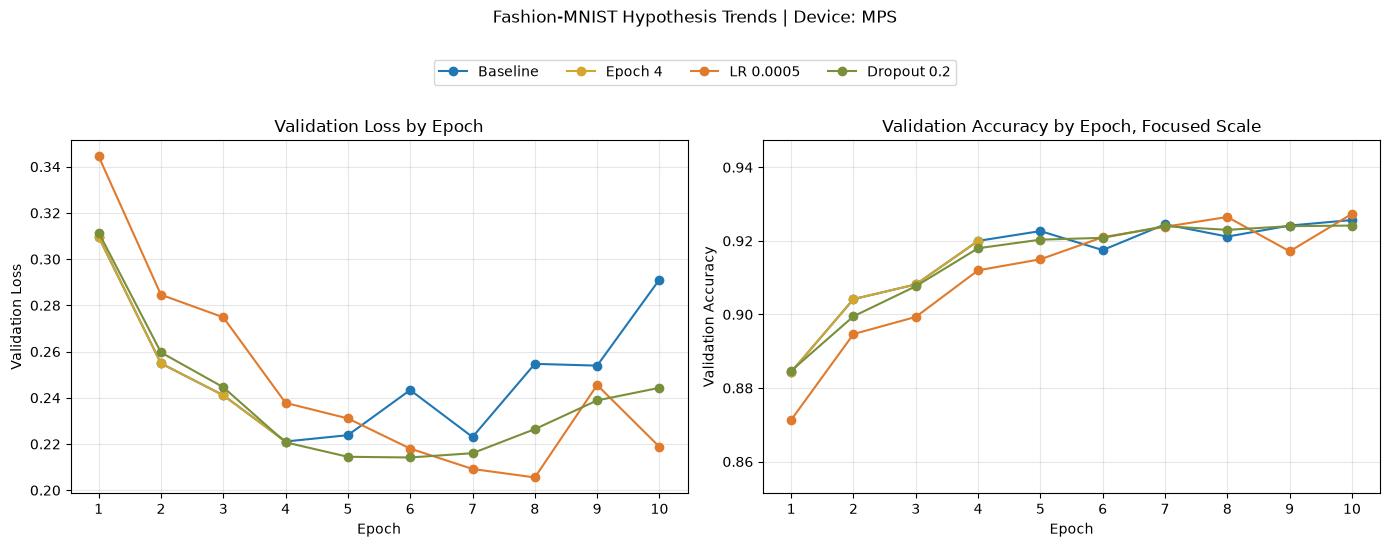

In [ ]:
MODEL_COLORS = {
    "Baseline": "#1f77b4",
    "김선정, Epoch 4": "#d4a72c",
    "임유리, LR 0.0005": "#e07a2d",
    "이민형, Dropout 0.2": "#7a8f3a",
}
GRAPH_LABELS = {
    "Baseline": "Baseline",
    "김선정, Epoch 4": "Epoch 4",
    "임유리, LR 0.0005": "LR 0.0005",
    "이민형, Dropout 0.2": "Dropout 0.2",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for name, history in experiment_histories.items():
    history_epochs = list(range(1, len(history["valid_loss"]) + 1))
    axes[0].plot(
        history_epochs,
        history["valid_loss"],
        marker="o",
        label=GRAPH_LABELS[name],
        color=MODEL_COLORS[name],
    )
    axes[1].plot(
        history_epochs,
        history["valid_accuracy"],
        marker="o",
        label=GRAPH_LABELS[name],
        color=MODEL_COLORS[name],
    )

axes[0].set_title("Validation Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_xticks(range(1, NUM_EPOCHS + 1))
axes[0].grid(alpha=0.3)

all_valid_accuracies = [
    accuracy
    for history in experiment_histories.values()
    for accuracy in history["valid_accuracy"]
]
accuracy_min = max(0.0, min(all_valid_accuracies) - 0.02)
accuracy_max = min(1.0, max(all_valid_accuracies) + 0.02)

axes[1].set_title("Validation Accuracy by Epoch, Focused Scale")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_xticks(range(1, NUM_EPOCHS + 1))
axes[1].set_ylim(accuracy_min, accuracy_max)
axes[1].grid(alpha=0.3)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.04))
fig.suptitle(f"Fashion-MNIST Hypothesis Trends | Device: {device.type.upper()}", y=1.13)
plt.tight_layout()
plt.show()

## 8. 최종 지표 비교 그래프

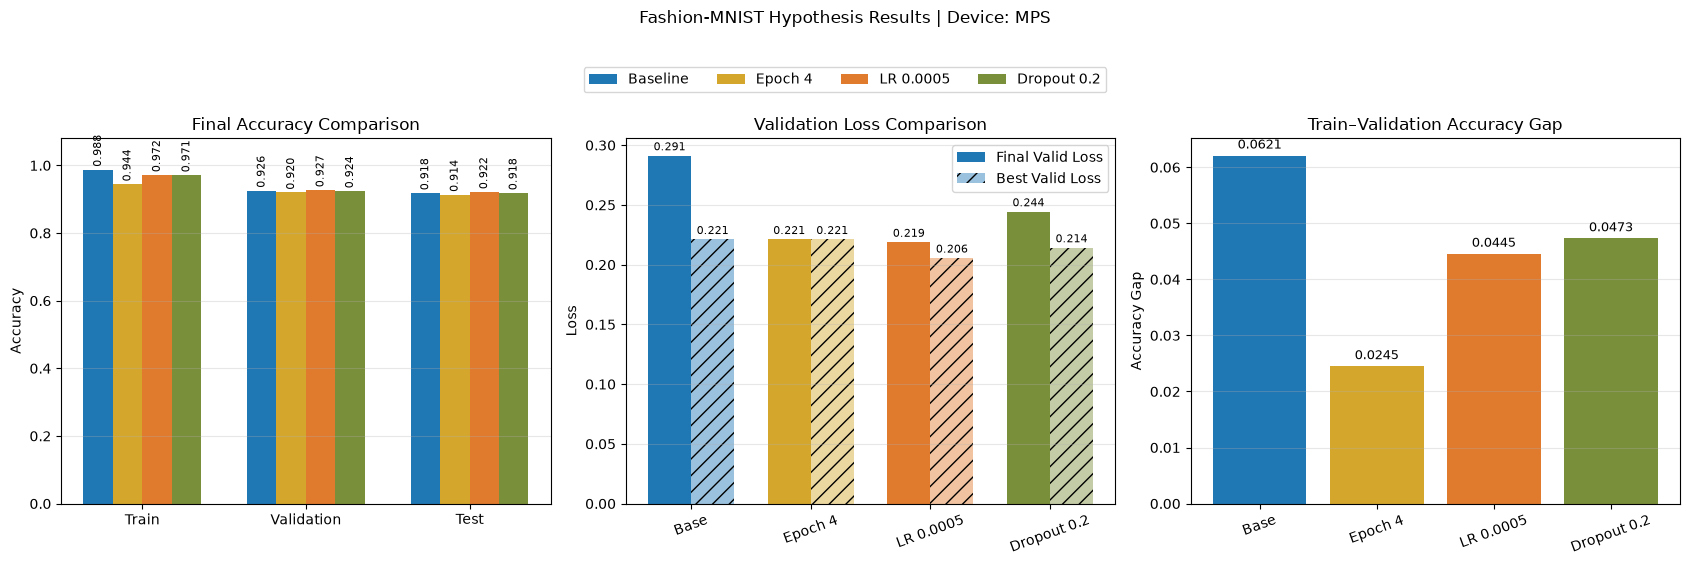

In [ ]:
names = [result["name"] for result in experiment_results]
colors = [MODEL_COLORS[name] for name in names]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Train, Validation, Test Accuracy
accuracy_labels = ["Train", "Validation", "Test"]
accuracy_keys = ["train_accuracy", "valid_accuracy", "test_accuracy"]
x_positions = list(range(len(accuracy_labels)))
bar_width = 0.18

for model_index, result in enumerate(experiment_results):
    offsets = [
        position + (model_index - 1.5) * bar_width
        for position in x_positions
    ]
    values = [result[key] for key in accuracy_keys]
    bars = axes[0].bar(
        offsets,
        values,
        width=bar_width,
        label=GRAPH_LABELS[result["name"]],
        color=MODEL_COLORS[result["name"]],
    )
    axes[0].bar_label(bars, fmt="%.3f", fontsize=8, rotation=90, padding=2)

axes[0].set_title("Final Accuracy Comparison")
axes[0].set_xticks(x_positions, accuracy_labels)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.0, 1.08)
axes[0].grid(axis="y", alpha=0.3)

# Final, Best Validation Loss
loss_x = list(range(len(names)))
final_loss_bars = axes[1].bar(
    [value - 0.18 for value in loss_x],
    [result["final_valid_loss"] for result in experiment_results],
    width=0.36,
    color=colors,
    label="Final Valid Loss",
)
best_loss_bars = axes[1].bar(
    [value + 0.18 for value in loss_x],
    [result["best_valid_loss"] for result in experiment_results],
    width=0.36,
    color=colors,
    alpha=0.45,
    hatch="//",
    label="Best Valid Loss",
)
axes[1].bar_label(final_loss_bars, fmt="%.3f", fontsize=8, padding=2)
axes[1].bar_label(best_loss_bars, fmt="%.3f", fontsize=8, padding=2)
axes[1].set_title("Validation Loss Comparison")
axes[1].set_xticks(loss_x, ["Base", "Epoch 4", "LR 0.0005", "Dropout 0.2"], rotation=20)
axes[1].set_ylabel("Loss")
axes[1].set_ylim(bottom=0.0)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

# Train-Validation Gap
gap_bars = axes[2].bar(
    range(len(names)),
    [result["generalization_gap"] for result in experiment_results],
    color=colors,
)
axes[2].bar_label(gap_bars, fmt="%.4f", fontsize=9, padding=3)
axes[2].set_title("Train–Validation Accuracy Gap")
axes[2].set_xticks(range(len(names)), ["Base", "Epoch 4", "LR 0.0005", "Dropout 0.2"], rotation=20)
axes[2].set_ylabel("Accuracy Gap")
axes[2].set_ylim(bottom=0.0)
axes[2].grid(axis="y", alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"Fashion-MNIST Hypothesis Results | Device: {device.type.upper()}", y=1.12)
plt.tight_layout()
plt.show()

## 9. 결과 해석 기준

- 김선정: 4 epoch의 최종 Validation Loss가 Baseline 10 epoch의 최종 Validation Loss보다 낮은지 확인한다.
- 임유리: Learning Rate 0.0005의 Best Validation Loss가 Baseline보다 낮은지 확인한다.
- 이민형: Dropout 0.2에서 Final Train Loss가 증가하면서 Final Validation Loss가 감소하는지 함께 확인한다.
- Test Accuracy가 높더라도 한 번의 실행만으로 일반적인 성능 우위를 확정하지 않는다.
- MPS, CUDA, CPU처럼 장치가 달라지면 부동소수점 연산 차이로 수치가 조금 달라질 수 있다.


# 실험 2. Dropout 0.1~0.5

In [ ]:
import gc

DROPOUT_SWEEP_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]
dropout_sweep_results = [baseline_record.copy()]
dropout_sweep_histories = {0.0: experiment_histories["Baseline"]}

for dropout_rate in DROPOUT_SWEEP_RATES:
    if dropout_rate == 0.2:
        result = lee_result.copy()
        result["name"] = "Dropout 0.2"
        history = lee_history
    else:
        result, history = run_experiment(
            name=f"Dropout {dropout_rate:.1f}",
            epochs=NUM_EPOCHS,
            learning_rate=LEARNING_RATE,
            dropout_p=dropout_rate,
        )

    dropout_sweep_results.append(result)
    dropout_sweep_histories[dropout_rate] = history
    gc.collect()
    torch.mps.empty_cache()


Dropout 0.1 | Epoch [01/10] Train Loss: 0.4375 | Valid Loss: 0.3123 | Valid Accuracy: 0.8850


Dropout 0.1 | Epoch [02/10] Train Loss: 0.2837 | Valid Loss: 0.2539 | Valid Accuracy: 0.9070


Dropout 0.1 | Epoch [03/10] Train Loss: 0.2371 | Valid Loss: 0.2436 | Valid Accuracy: 0.9093


Dropout 0.1 | Epoch [04/10] Train Loss: 0.2044 | Valid Loss: 0.2259 | Valid Accuracy: 0.9208


Dropout 0.1 | Epoch [05/10] Train Loss: 0.1776 | Valid Loss: 0.2222 | Valid Accuracy: 0.9188


...

Dropout 0.5 | Epoch [06/10] Train Loss: 0.2280 | Valid Loss: 0.2231 | Valid Accuracy: 0.9143


Dropout 0.5 | Epoch [07/10] Train Loss: 0.2103 | Valid Loss: 0.2263 | Valid Accuracy: 0.9158


Dropout 0.5 | Epoch [08/10] Train Loss: 0.1957 | Valid Loss: 0.2134 | Valid Accuracy: 0.9205


Dropout 0.5 | Epoch [09/10] Train Loss: 0.1832 | Valid Loss: 0.2275 | Valid Accuracy: 0.9218


Dropout 0.5 | Epoch [10/10] Train Loss: 0.1715 | Valid Loss: 0.2265 | Valid Accuracy: 0.9238


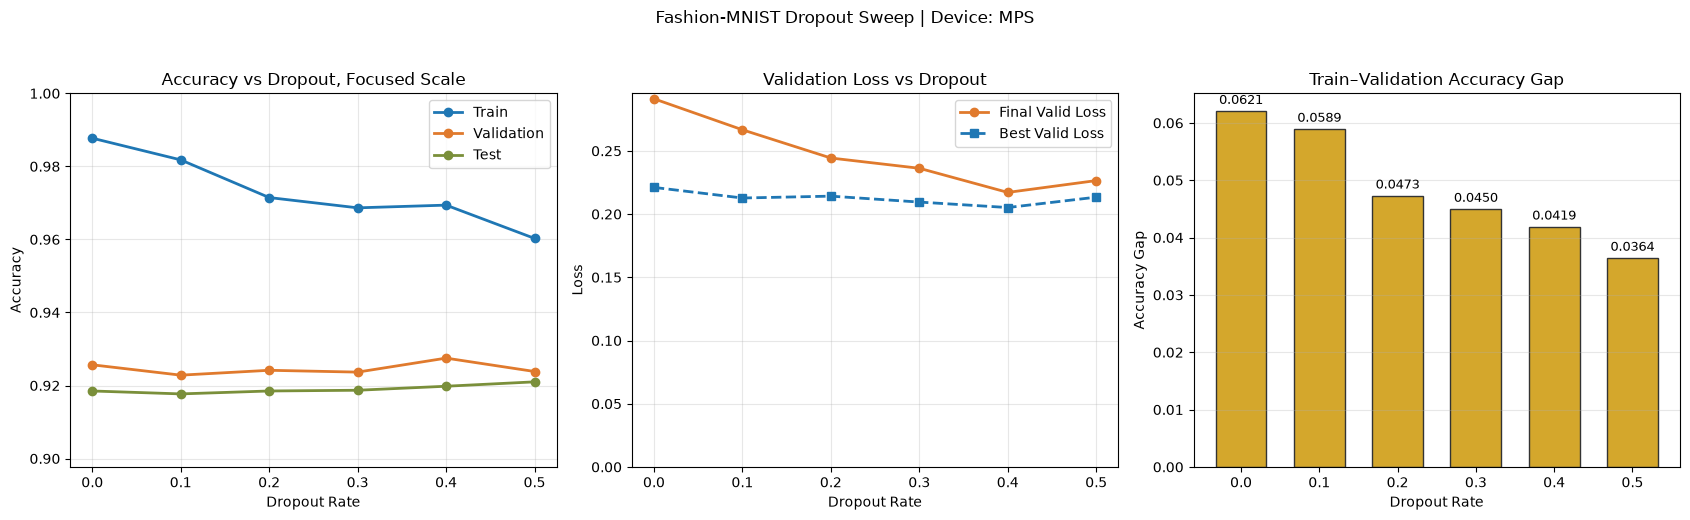

In [ ]:
dropout_values = [result["dropout"] for result in dropout_sweep_results]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

accuracy_series = {
    "Train": [result["train_accuracy"] for result in dropout_sweep_results],
    "Validation": [result["valid_accuracy"] for result in dropout_sweep_results],
    "Test": [result["test_accuracy"] for result in dropout_sweep_results],
}
accuracy_colors = {
    "Train": "#1f77b4",
    "Validation": "#e07a2d",
    "Test": "#7a8f3a",
}

for label, values in accuracy_series.items():
    axes[0].plot(
        dropout_values,
        values,
        marker="o",
        linewidth=2,
        label=label,
        color=accuracy_colors[label],
    )

all_accuracy_values = [
    value for values in accuracy_series.values() for value in values
]
axes[0].set_ylim(
    max(0.0, min(all_accuracy_values) - 0.02),
    min(1.0, max(all_accuracy_values) + 0.02),
)
axes[0].set_title("Accuracy vs Dropout, Focused Scale")
axes[0].set_xlabel("Dropout Rate")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(dropout_values)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    dropout_values,
    [result["final_valid_loss"] for result in dropout_sweep_results],
    marker="o",
    linewidth=2,
    label="Final Valid Loss",
    color="#e07a2d",
)
axes[1].plot(
    dropout_values,
    [result["best_valid_loss"] for result in dropout_sweep_results],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Best Valid Loss",
    color="#1f77b4",
)
axes[1].set_title("Validation Loss vs Dropout")
axes[1].set_xlabel("Dropout Rate")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(dropout_values)
axes[1].set_ylim(bottom=0.0)
axes[1].grid(alpha=0.3)
axes[1].legend()

gap_values = [
    result["generalization_gap"] for result in dropout_sweep_results
]
gap_bars = axes[2].bar(
    dropout_values,
    gap_values,
    width=0.065,
    color="#d4a72c",
    edgecolor="#333333",
)
axes[2].bar_label(gap_bars, fmt="%.4f", fontsize=9, padding=3)
axes[2].set_title("Train–Validation Accuracy Gap")
axes[2].set_xlabel("Dropout Rate")
axes[2].set_ylabel("Accuracy Gap")
axes[2].set_xticks(dropout_values)
axes[2].set_ylim(bottom=0.0)
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle(
    f"Fashion-MNIST Dropout Sweep | Device: {device.type.upper()}",
    y=1.03,
)
plt.tight_layout()
plt.show()

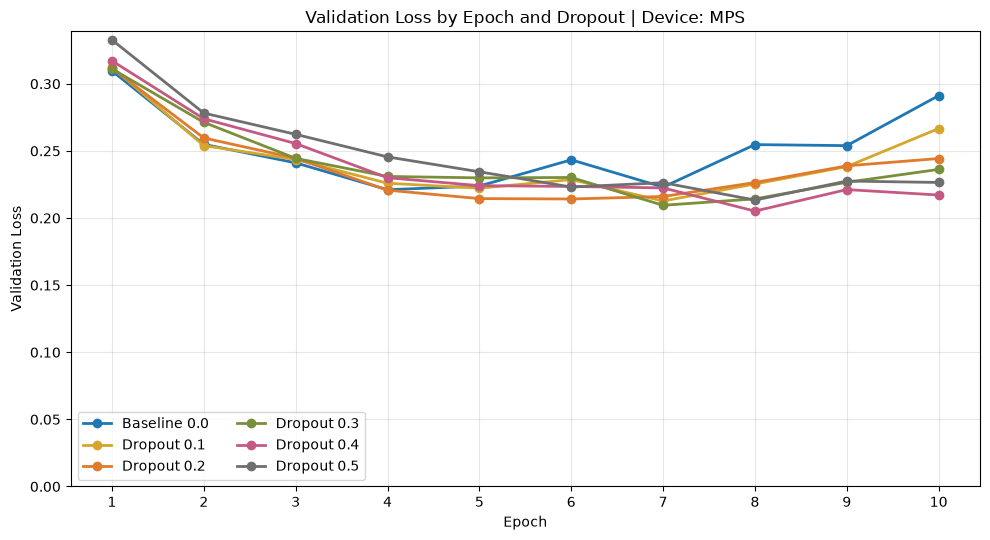

In [ ]:
DROPOUT_COLORS = {
    0.0: "#1f77b4",
    0.1: "#d4a72c",
    0.2: "#e07a2d",
    0.3: "#7a8f3a",
    0.4: "#c45a84",
    0.5: "#6f6f6f",
}

plt.figure(figsize=(10, 5.5))

for dropout_rate in sorted(dropout_sweep_histories):
    history = dropout_sweep_histories[dropout_rate]
    history_epochs = range(1, len(history["valid_loss"]) + 1)
    label = "Baseline 0.0" if dropout_rate == 0.0 else f"Dropout {dropout_rate:.1f}"

    plt.plot(
        history_epochs,
        history["valid_loss"],
        marker="o",
        linewidth=2,
        label=label,
        color=DROPOUT_COLORS[dropout_rate],
    )

plt.title(f"Validation Loss by Epoch and Dropout | Device: {device.type.upper()}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.ylim(bottom=0.0)
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()